## Problem Statement

The institution (bank) is experiencing a significant 30% default rate within its credit portfolio, with certain loan segments reaching default probabilities as high as 54.2%. While the average loan size is relatively modest (R3,271), the "bad" risk profiles are concentrated in specific behavioral and demographic clusters,most notably within car loan applicants and this leads to disproportionate financial losses. There is a critical need to identify these high-exposure segments and implement prescriptive lending constraints to reduce the overall portfolio risk and minimize the average loss per customer, which currently peaks at R7,931 in the most vulnerable segments.

## Executive Summary

This analysis evaluates a dataset of 1,000 credit applicants to identify key drivers of default and provide data-driven lending constraints. The primary objective is to mitigate financial exposure in high-risk demographic and behavioral segments.

Core Data Insights
Dataset Composition: The analysis covers 1,000 entries with an average credit amount of R3,271 and an average loan duration of ~21 months.

Risk Distribution: The portfolio currently maintains a split of 700 "good" risk profiles and 300 "bad" risk profiles (30% default rate).

Critical Risk Zones
The "Car Loan Trap": Car loans represent a significant high-risk category. Specifically, applicants with Free Housing and Little Checking liquidity show a spike in default rates to 54.2%.

Maximum Financial Exposure: The highest average loss per customer (R7,931) is found among homeowners with "Moderate Checking" accounts taking out car loans. This group represents a higher financial risk despite having ostensibly better liquidity than the "Little Checking" group.

Prescriptive Recommendations
To stabilize the portfolio and reduce losses, the following strategic measures are proposed:

Liquidity-Based Lending Caps: Implement a strict credit limit of R3,500 for any applicant categorized in the "Little" checking account segment due to the high Information Value (IV) of this variable.

Collateral Requirements (Strategic Pledging): For the high-exposure segment (averaging R7,931 in loss), require a Pledged Amount (collateral) equal to 40% of the loan value to offset the 50% default probability.

Duration Reform: For high-risk profiles, reduce the maximum allowable duration for car loans from 72 months to 36 months. Data indicates that higher loan durations are strongly correlated with increased default rates.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [247]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", None)

In [248]:
sns.set_style("whitegrid")

In [291]:
url = "https://raw.githubusercontent.com/Edwardm1276/Credit-Risk-Analysis/main/credit_data.csv"
df = pd.read_csv(url)
df.head(5)


,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [292]:
df = df.drop(columns="Unnamed: 0")
df.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,49,male,1,own,little,NaN,2096,12,education,good
3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,53,male,2,free,little,little,4870,24,car,bad


In [293]:
df.describe()

,Age,Job,Credit amount,Duration
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,35.546000,1.904000,3271.258000,20.903000
std,11.375469,0.653614,2822.736876,12.058814
min,19.000000,0.000000,250.000000,4.000000
25%,27.000000,2.000000,1365.500000,12.000000
50%,33.000000,2.000000,2319.500000,18.000000
75%,42.000000,2.000000,3972.250000,24.000000
max,75.000000,3.000000,18424.000000,72.000000


## Exploratory Data Analysis

Risk
good    700
bad     300
Name: count, dtype: int64


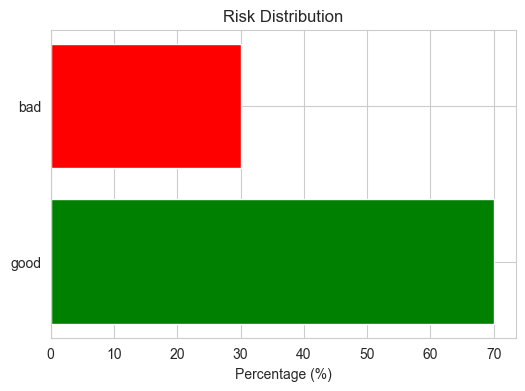

In [294]:
risk_counts = df['Risk'].value_counts()
risk_percentages = (risk_counts / len(df)) *100
print(risk_counts)
plt.figure(figsize=(6,4))
plt.barh(risk_counts.index, risk_percentages.values, color=['green', 'red'])
plt.xlabel('Percentage (%)')
plt.title('Risk Distribution')
plt.show()

The risk distribution was conducted to observe the balance of the dataset to ensure that the model will see enough "bad" and "good" cases to learn patterns sufficiently. The other reason was to gauge how risky the population is over.
A 70% good / 30% bad distribution means a moderate risk population
Although the distribution shows a workable balance between good/bad risk, 30% default risk is not a good number, so we need a significant separation between good and bad borrowers. 

In [295]:
# Missing Values
print(df.isnull().mean()*100)

Age                  0.0
Sex                  0.0
Job                  0.0
Housing              0.0
Saving accounts     18.3
Checking account    39.4
Credit amount        0.0
Duration             0.0
Purpose              0.0
Risk                 0.0
dtype: float64


<Figure size 800x400 with 0 Axes>

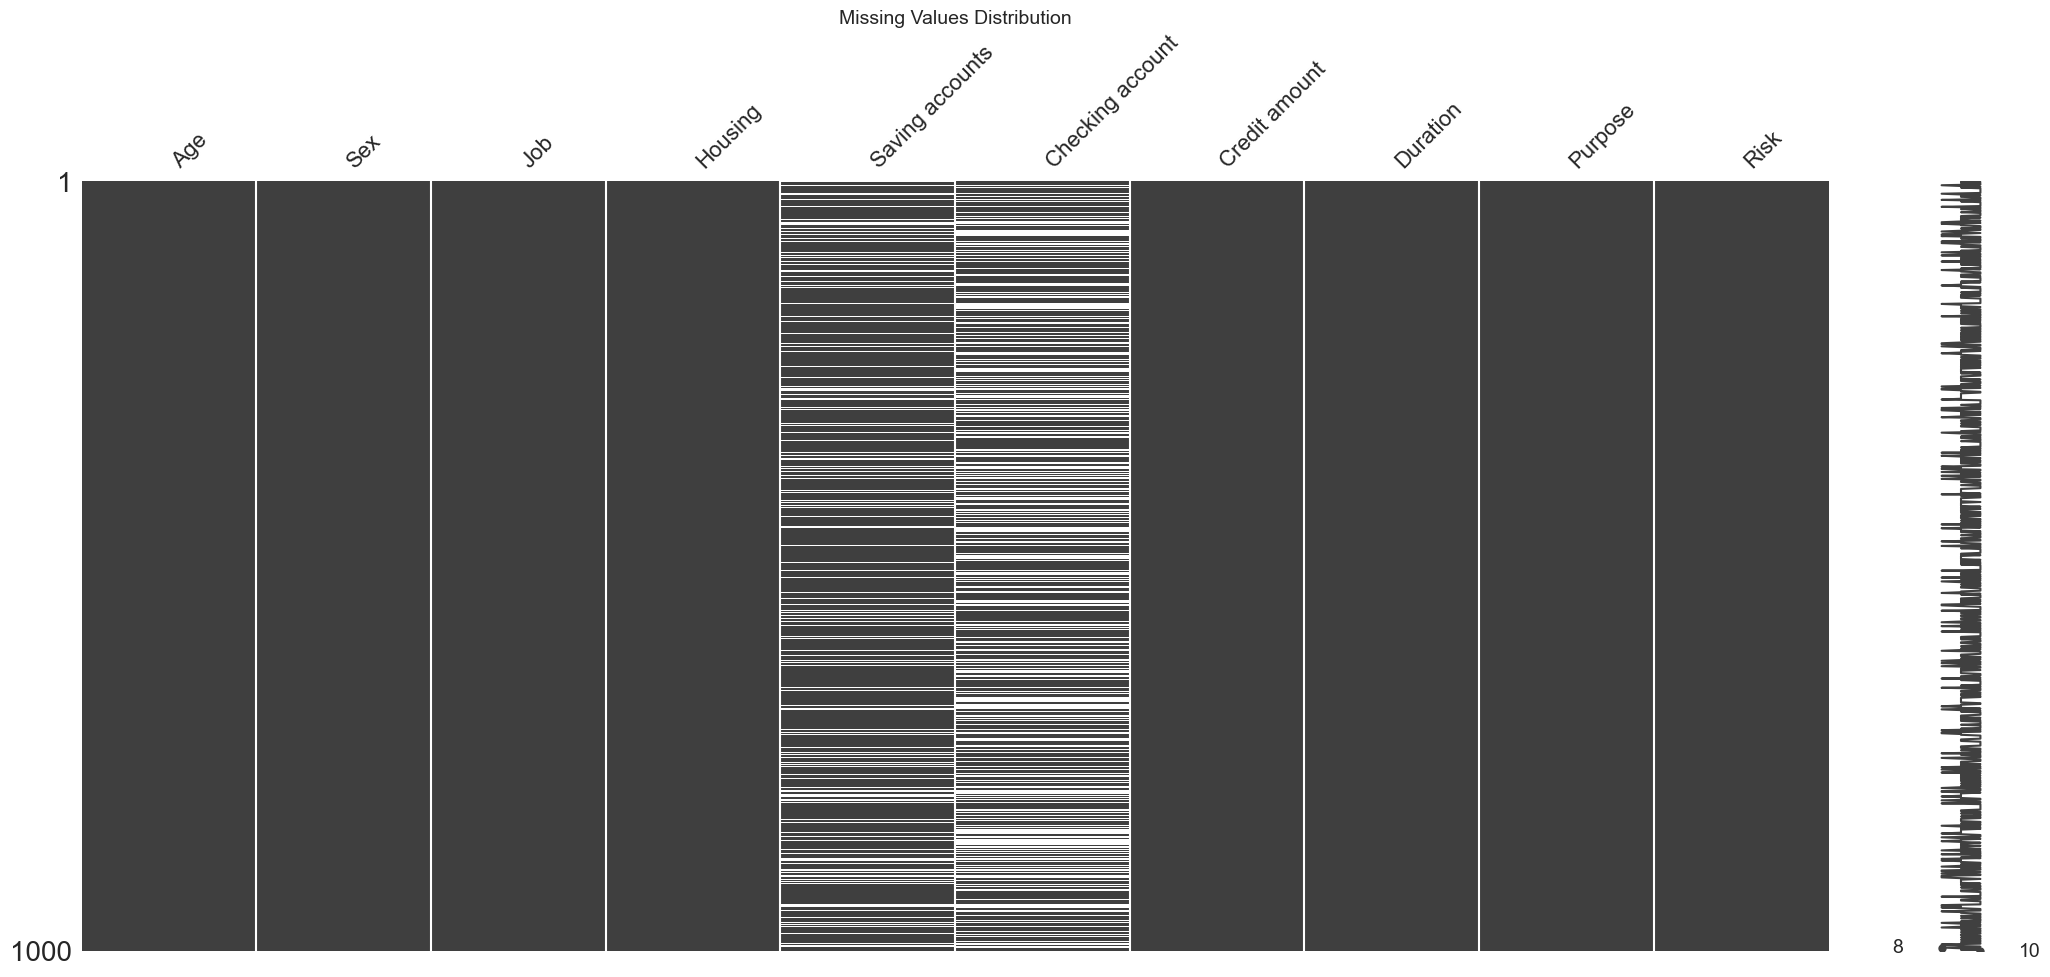

In [296]:
import statistics
import missingno as msno

# Missing entries distribution
plt.figure(figsize=(8, 4))
msno.matrix(df)
plt.title('Missing Values Distribution', fontsize = 14, loc ='center')
plt.tight_layout()
plt.show()

The distribution of null/missing values in our data does not follow a pattern across the two variables, so we cannot conclude that there is correlation in their missingness. If there was, then that customer type with no accounts at all would be a distinct segment with unique risk characteristics. 

## Information Value

We are going to calculate the information value of the variables, to better get an indication of which values are best at predicting defaulting.
Higher IV = better predictor of good/bad ris

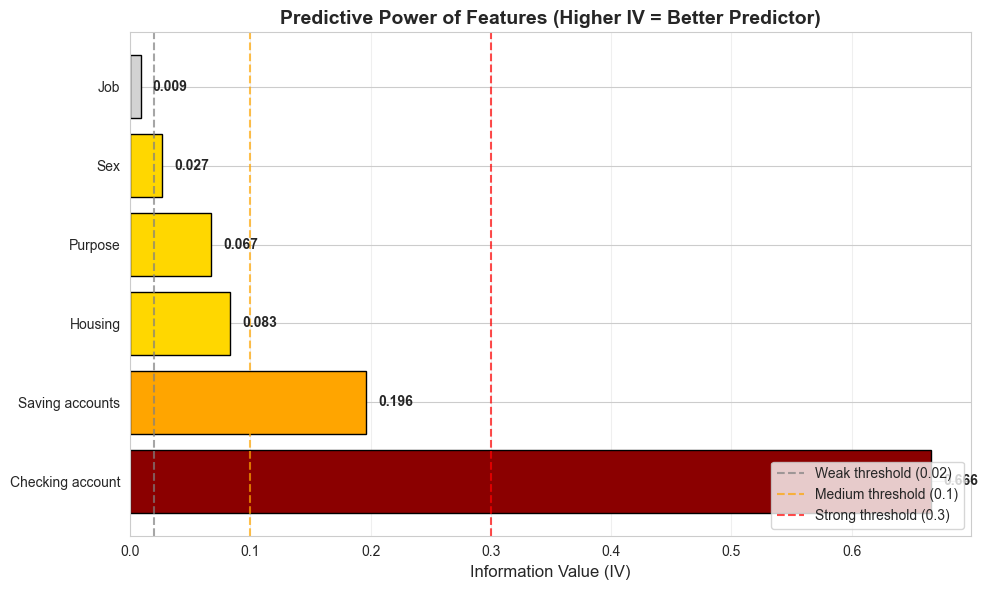

In [297]:
def calculate_iv(data, feature, target='Risk'):
   
    cross_tab = pd.crosstab(data[feature], data[target], margins=False, dropna=False)
    
    cross_tab = cross_tab
    
    # Calculate distribution of good and bad
    good_dist = cross_tab['good'] / cross_tab['good'].sum()
    bad_dist = cross_tab['bad'] / cross_tab['bad'].sum()
    
    # Calculate WOE and IV
    woe = np.log(good_dist / bad_dist)
    iv = np.sum((good_dist - bad_dist) * woe)
    
    return iv

# Calculate IV for all categorical variables
categorical_features = ['Checking account', 'Saving accounts', 'Purpose', 'Housing', 'Sex', 'Job']

iv_results = {}
for feature in categorical_features:
    iv = calculate_iv(df, feature)
    iv_results[feature] = iv


iv_sorted = pd.DataFrame(list(iv_results.items()), columns=['Feature', 'IV']).sort_values('IV', ascending=False)
iv_sorted['Interpretation'] = iv_sorted['IV'].apply(lambda x: 
    'Strong' if x > 0.3 else ('Medium' if x > 0.1 else ('Weak' if x > 0.02 else 'Not predictive')))

iv_visual = iv_sorted.copy()
iv_visual['Color'] = iv_visual['IV'].apply(lambda x: 
    'darkred' if x > 0.3 else ('orange' if x > 0.1 else ('gold' if x > 0.02 else 'lightgray')))


plt.figure(figsize=(10, 6))
bars = plt.barh(iv_visual['Feature'], iv_visual['IV'], color=iv_visual['Color'], edgecolor='black')


for bar, iv in zip(bars, iv_visual['IV']):
    plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, f'{iv:.3f}', 
             va='center', fontsize=10, fontweight='bold')

# Thresholds
plt.axvline(x=0.02, color='gray', linestyle='--', alpha=0.7, label='Weak threshold (0.02)')
plt.axvline(x=0.1, color='orange', linestyle='--', alpha=0.7, label='Medium threshold (0.1)')
plt.axvline(x=0.3, color='red', linestyle='--', alpha=0.7, label='Strong threshold (0.3)')

plt.xlabel('Information Value (IV)', fontsize=12)
plt.title('Predictive Power of Features (Higher IV = Better Predictor)', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

This shows us that a customer's checking account status is by far the most important factor in predicting default, it is 3.4 times more predictive than the second best variable in this dataset, saving account. This then justifies us to use it as the focal point of our analysis, with other variables being introduced as well to be transposed with risk to determine the proporitions of good and bad risk of our segments.

In [298]:
value_values = df['Checking account'].unique()
value_counts = df['Checking account'].value_counts(dropna=False)
print(value_counts)

Checking account
NaN         394
little      274
moderate    269
rich         63
Name: count, dtype: int64


In [299]:
CrossTabulation = pd.crosstab(df['Checking account'],df['Risk'], dropna=False, normalize='index')* 100
print(CrossTabulation.round(2))

Risk                bad   good
Checking account              
little            49.27  50.73
moderate          39.03  60.97
rich              22.22  77.78
NaN               11.68  88.32


Before analysis, it is important to note that there is no apparent way of determining how exactly the catergories "little", "moderate", and "rich" were determined. There are no numerical figures for us to gauge what is considered as "little" money in the check account.
 
-The tabulation shows that 49% of the lenders with little amounts in their check account are at risk of defaulting

-Moderate is at a lower risk at 39% but it is still a significant risk

-22% of rich lenders are at risk of defaulting, this can be attributed to their credit amounts possibly being higher. It may be useful to verify this by computing the avergae credit amount by checking account category

-It is surprising that the percentage of defaults is lowest in the category of lenders with no check accounts, one would make an assumption that not having a check account would cause suspicion, but the data does not agree with the assumption

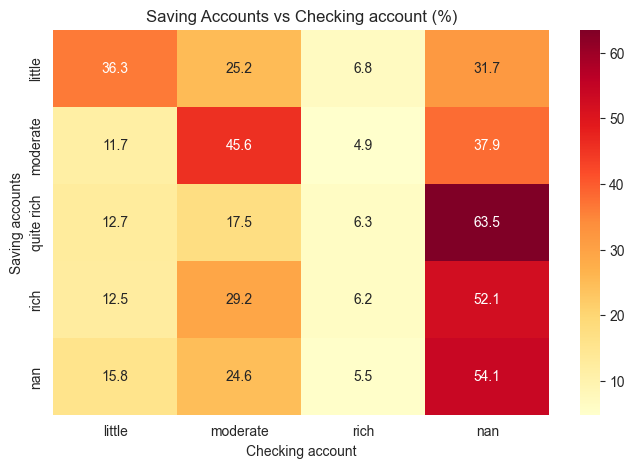

In [300]:
saving_stats = pd.crosstab(df['Saving accounts'], df['Checking account'], normalize='index', dropna=False) * 100
plt.figure(figsize=(8, 5))
sns.heatmap(saving_stats, annot=True, fmt='.1f', cmap='YlOrRd')
plt.title('Saving Accounts vs Checking account (%)')
plt.show()

It is beneficial to inspect the proportions of the customer base who have checking accounts when compared to those with savings accounts, this lets us know the financial strength of the different segments of customer. We can see the segment with missing checking accounts has a high financial strength while the the segment with little checking amount has weak financial strength. The moderate segment has a fairly balanced distribution of financial strength.

Average credit per segment:  Checking account
moderate    3827.56
little      3175.22
NaN         3133.10
rich        2177.65
Name: Credit amount, dtype: float64


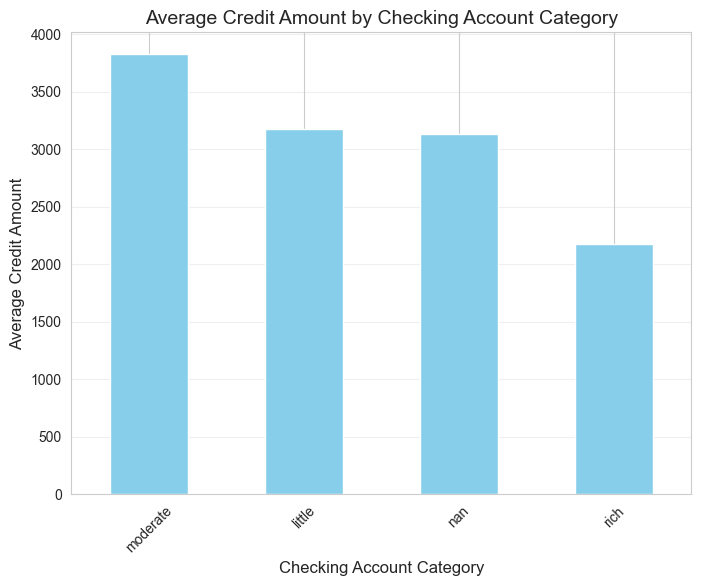

In [301]:
avg_credit = df.groupby('Checking account', dropna=False)['Credit amount'].mean().sort_values(ascending=False)
plt.figure(figsize=(8, 6))
avg_credit.plot(kind='bar', color='skyblue')
plt.title('Average Credit Amount by Checking Account Category', fontsize=14)
plt.xlabel('Checking Account Category', fontsize=12)
plt.ylabel('Average Credit Amount', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
print("Average credit per segment: ", avg_credit.round(2))

The visualization shows that the group with the highest percentage of default risk having the highest average credit amount, and this is not good, it signals that the bank stands lose a lot of money as long as this pattern persists. The credit amounts and default percentages are counter-intuitive because the safest lenders seem to be getting lower credit amounts than riskier lenders
To simulate the ramifications of this, we need to conduct Expected Loss computation for all categories, we will use housing as a categorical variable to encode in such a way that we can obtain a mapping for Loss Given Default(LGD)

Expected Loss = Probability of Default * Average credit * Average LGD * Number of customers

In [302]:
# LGD proxy based on Housing
lgd_map = {
    'own': 0.60,
    'rent': 0.90,
    'free': 0.80
}


stats = pd.crosstab(df['Saving accounts'], df['Housing'], normalize='index', dropna=False)*100
saving = pd.DataFrame({
    'Own %': stats['own'].round(1),
    'Rent %': stats['free'].round(1),
    'Free %': stats['rent'].round(1)
})
print( saving)
print('')

                 Own %  Rent %  Free %
Saving accounts                       
little            71.3    11.1    17.6
moderate          68.9     9.7    21.4
quite rich        71.4     9.5    19.0
rich              77.1     4.2    18.8
NaN               71.0    12.6    16.4



An overwhelming amount of customers own their houses (69%-77%) across the segments, this is good for collateral since property fits the MAST Framework. 
This then means we can assign the Loss Given Default of home owners at 60%, allowing us to recover 40% in the event of a default, from the sale of the property. 

The non-homeowners will have a big LGD since there is no collateral, with 'rent' having 90% LDG, which allows a 10% recovery from either savings account or check account, similarly 'free' segment will have 80% LGD since they do not have to pay rent, providing them with more disposable income. 



PREDICTIVE EXPECTED LOSS by Checking Account Category:
                  Customers  P(Bad)  Avg Credit  Avg LGD  Predicted EL
Checking account                                                      
little                  274    49.3      3175.0     70.0      301883.0
moderate                269    39.0      3828.0     68.0      278685.0
rich                     63    22.2      2178.0     66.0       19916.0
NaN                     394    11.7      3133.0     66.0       95749.0


OVERALL PREDICTIVE EXPECTED LOSS:
Total Expected Loss: R696233.5
Total Exposure: R3271258 
Expected Loss Rate: 21.28%


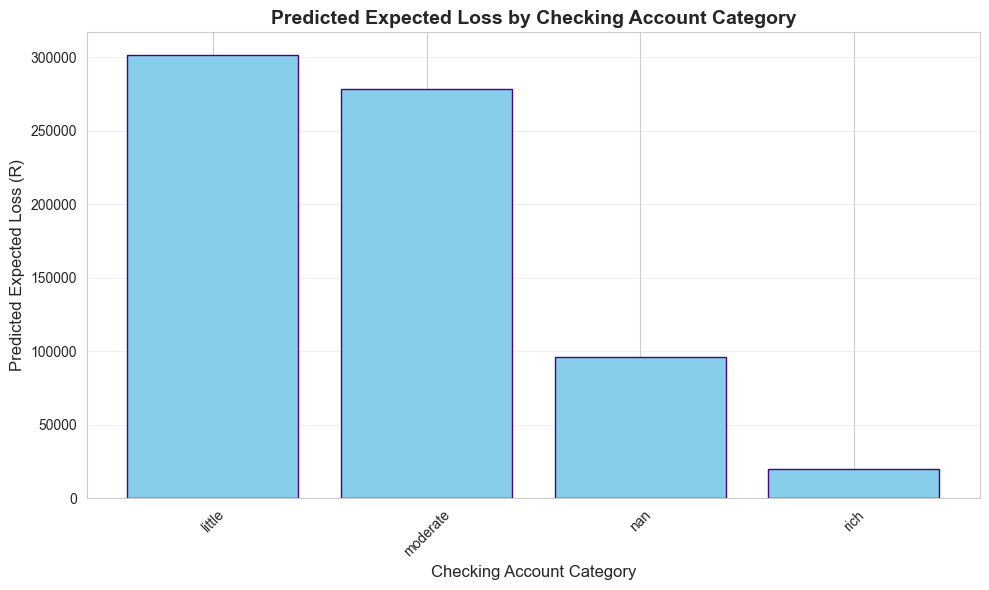

In [303]:
p_bad = pd.crosstab(df['Checking account'], df['Risk'], normalize='index', dropna=False)['bad']

# Map P(Bad) to each customer based on their checking account category
df['P_Bad'] = df['Checking account'].map(p_bad)

# Map LGD per customer
df['LGD'] = df['Housing'].map(lgd_map)


# EL = P(Bad) × Credit Amount × LGD (using segment probability, not actual outcome)
df['predicted_EL'] = df['P_Bad'] * df['Credit amount'] * df['LGD']

# Sum by checking account category
el_by_category = df.groupby('Checking account', dropna=False)['predicted_EL'].sum().sort_values(ascending=False)


el_summary = pd.DataFrame({
    'Customers': df.groupby('Checking account', dropna=False).size(),
    'P(Bad)': (p_bad * 100).round(1),
    'Avg Credit': df.groupby('Checking account', dropna=False)['Credit amount'].mean().round(0),
    'Avg LGD': (df.groupby('Checking account', dropna=False)['LGD'].mean() * 100).round(0),
    'Predicted EL': el_by_category.round(0)
})

print("PREDICTIVE EXPECTED LOSS by Checking Account Category:")
print(el_summary)
print("")

# Total predictive expected loss
total_predicted_el = el_by_category.sum()
total_exposure = df['Credit amount'].sum()

print(f"\nOVERALL PREDICTIVE EXPECTED LOSS:")
print(f"Total Expected Loss: R{total_predicted_el.round(2)}")
print(f"Total Exposure: R{total_exposure.round(2)} ")
print(f"Expected Loss Rate: {(total_predicted_el / total_exposure * 100).round(2)}%")

el_by_category = df.groupby('Checking account', dropna=False)['predicted_EL'].sum().sort_values(ascending=False)


plt.figure(figsize=(10, 6))
bars = plt.bar(range(len(el_by_category)), el_by_category.values, color='skyblue', edgecolor='indigo')
plt.title('Predicted Expected Loss by Checking Account Category', fontsize=14, fontweight='bold')
plt.xlabel('Checking Account Category', fontsize=12)
plt.ylabel('Predicted Expected Loss (R)', fontsize=12)
plt.xticks(range(len(el_by_category)), el_by_category.index, rotation=45)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

The computation used segment probability instead of actual outcome because the aim of predicting the expected loss was to calculate the loss we expect for future customers in that segment, rather than backward looking on the specific customers in the dataset. I took this approach because of the size of the dataset being too small in relation to real bank data.

It is obviously erronous that the highest risk groups have the highest average credit amounts, leading to a huge disparity in Expected Loss between the high risk groups and the low risk groups, this is where the bank will lose the most money. Based on the Expected Loss and the average credit amount of the categories, it is imperative that the bank focuses on achieving a middle ground between giving loans to lenders that are likely to not default while also focusing on groups that incur a lot of credit. For this balance to occur, we need to find another distinguishing measure that will make it a bit clearer on who within the "little" Checking account category can be a good risk, or else put measure in place to ensure that should a high risk group defualt, we have recouped a lot of money. 

We can:
- Adjust loan size so that high risk groups can get smaller loans
- Adjust interest rates to charge more to high risk groups, safeguarding for in case they default

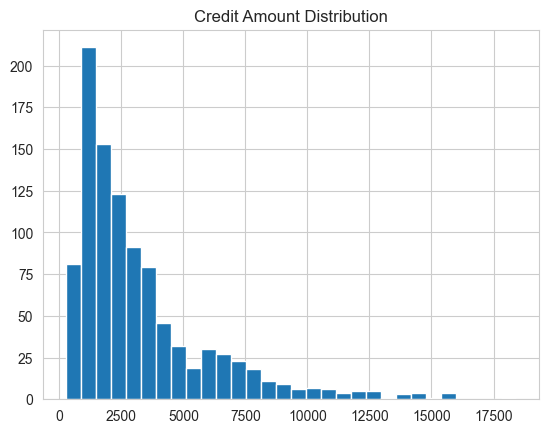

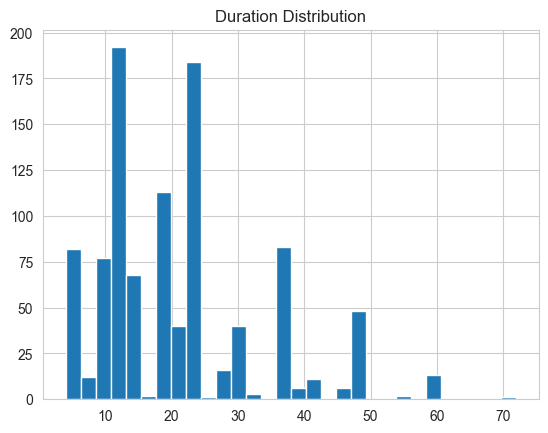

In [304]:
# Credit amount distribution
df['Credit amount'].hist(bins=30)
plt.title('Credit Amount Distribution')
plt.show()

# Duration distribution
df['Duration'].hist(bins=30)
plt.title('Duration Distribution')
plt.show()

We can see our data shows many small loans, and a few large ones, above R7 500. The skew signified by the cluster on the left gives us an indication of lower losses should there by defaults, while larger loans show high exposure. One default by the outliers can cause major loss for the bank, so the skew is welcomed. 

 80th percentile -> R 4720: 200 loans, 42.5% bad
 85th percentile -> R 5970: 150 loans, 46.0% bad
 90th percentile -> R 7179: 100 loans, 47.0% bad
 95th percentile -> R 9163: 50 loans, 58.0% bad


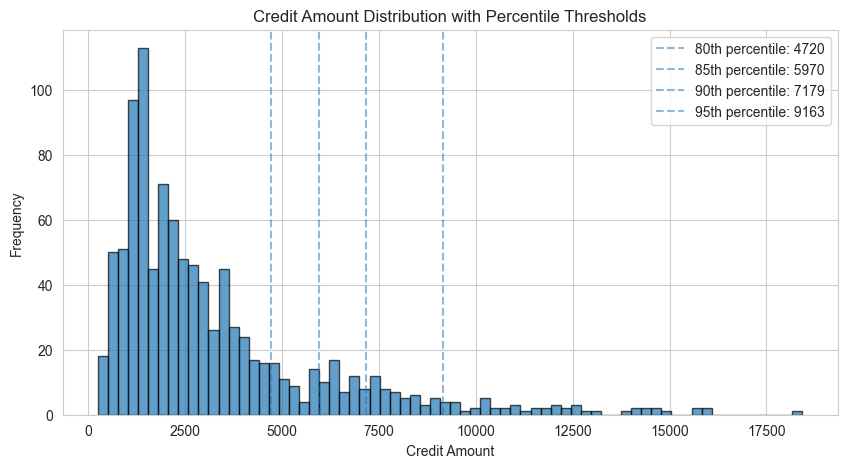

In [305]:
# Calculate various thresholds
percentiles =  [80,85,90,95]
thresholds = {f"{p}th percentile": df['Credit amount'].quantile(p/100) for p in percentiles}

# See what % of bad risks are in each percentile
for name, threshold in thresholds.items():
    high_group = df[df['Credit amount'] > threshold]
    bad_pct = (high_group['Risk'] == 'bad').mean() * 100
    print(f" {name} -> R {threshold:.0f}: {len(high_group)} loans, {bad_pct:.1f}% bad")


plt.figure(figsize=(10, 5))
plt.hist(df['Credit amount'], bins=70, edgecolor='black', alpha=0.7)
for name, threshold in thresholds.items():
    plt.axvline(threshold, linestyle='dashed', alpha=0.5, label=f"{name}: {threshold:.0f}")
plt.xlabel('Credit Amount')
plt.ylabel('Frequency')
plt.title('Credit Amount Distribution with Percentile Thresholds')
plt.legend()
plt.show()


The visual alerts us that risk increases with loan size, it took a major spike from the 90th percentile to the 95th percentile. It is also worth noting that all the large loans (from 80th percentiles) have an extremely high proability of default, so it is worth revising our lending policy to determine how to best allocate large loans. 

# Finding more precise risk profiles

In [306]:
# Multi-variable segmentation
# 3 variables (Checking + Purpose + Housing)
worst_segments = df.groupby(['Checking account', 'Purpose', 'Housing']).agg(
    bad_pct=('Risk', lambda x: (x == 'bad').mean() * 100),
    count=('Risk', 'count'),
    avg_credit=('Credit amount', 'mean')
).sort_values('bad_pct', ascending=False)

print("\nWorst segments by Checking + Purpose + Housing (min 10 customers):")
print(worst_segments[worst_segments['count'] >= 10].head(10))


Worst segments by Checking + Purpose + Housing (min 10 customers):
                                                bad_pct  count   avg_credit
Checking account Purpose             Housing                               
little           car                 free     54.166667     24  5125.916667
                 radio/TV            rent     53.846154     13  2219.384615
moderate         car                 free     50.000000     12  7931.083333
                 furniture/equipment rent     50.000000     10  3085.600000
little           furniture/equipment rent     50.000000     20  2706.400000
                 car                 rent     50.000000     22  2498.772727
moderate         car                 rent     47.368421     19  4522.578947
little           car                 own      46.551724     58  2897.913793
moderate         furniture/equipment own      46.428571     28  3468.535714
little           radio/TV            own      45.945946     37  2298.000000


In [307]:
worst_segments_2 = df.groupby(['Purpose', 'Duration', 'Job']).agg(
    bad_pct=('Risk', lambda x: (x == 'bad').mean() * 100),
    count=('Risk', 'count'),
    avg_credit=('Credit amount', 'mean')
).sort_values('bad_pct', ascending=False)

print("\nWorst segments by Purpose + Duration + Job (min 10 customers):")
print(worst_segments_2[worst_segments_2['count'] >= 10].head(10))


Worst segments by Purpose + Duration + Job (min 10 customers):
                                    bad_pct  count   avg_credit
Purpose             Duration Job                               
car                 18       2    55.555556     18  2918.666667
                    48       2    54.545455     11  6826.636364
                    36       2    45.000000     20  6351.600000
furniture/equipment 18       2    42.857143     21  2615.095238
car                 12       1    40.000000     15  1451.133333
                             2    38.235294     34  1950.794118
radio/TV            12       1    35.714286     14  1348.071429
                    18       2    30.434783     23  2231.956522
                    9        2    30.000000     10  1719.200000
car                 36       3    30.000000     10  7901.100000


This segmentation focuses on the combination of factors affecting risk, without necessarily looking at the financial standing of the borrower, it may give insight into demographic or behavioral patterns of the borrower

In [308]:
# Full segmentation with all risk predictors
worst_segments_full = df.groupby(['Checking account', 'Purpose', 'Housing', 'Duration']).agg(
    bad_pct=('Risk', lambda x: (x == 'bad').mean() * 100),
    count=('Risk', 'count'),
    avg_credit=('Credit amount', 'mean')
).sort_values('bad_pct', ascending=False)

print("Full segmentation (min 10 customers):")
print(worst_segments_full[worst_segments_full['count'] >= 10].head(10))

Full segmentation (min 10 customers):
                                                         bad_pct  count  \
Checking account Purpose             Housing Duration                     
little           car                 own     12        58.823529     17   
                 furniture/equipment own     24        40.000000     10   
moderate         radio/TV            own     12        33.333333     12   
                 car                 own     12        23.076923     13   

                                                        avg_credit  
Checking account Purpose             Housing Duration               
little           car                 own     12        1637.529412  
                 furniture/equipment own     24        3874.700000  
moderate         radio/TV            own     12        1937.666667  
                 car                 own     12        1919.000000  


There are various ways the bank can take to maximize recovery from defaults of customers with no housing or are renting. 
Wage garnishment is highly feasible if the bank has legal recourse, there is another option of bank account seizure, but it has guarantees since by the time of freezing, the customer might not have any money in their account. 
There is another option to create a pledge amount in the savings account of the borrower (which they will create if none exists). The pledged amount will be 10% of the remaining credit owed to the bank at any instance from the initialization of the loan. That way, if the borrower defaults, the bank can still recoup  10% of the remaining amount owed to it. 

## Housing based solutions

For renters and free-housing customers:

Require direct debit authorization for bank to pull payments automatically

Keep loan sizes small so wage garnishment is easy to implement

## Car loans based LGD


For car loans specifically, we can consider the car itself as collateral but this is predicated on the assumption that the car is fully bought with the loan amount, and this assumption can easily be false. Since we don't have loan-to-value ratio, we can use more conservative estimates of the LGD for car loans. We can assume 65% LGD for car loans, and this is a limitation for our analysis, so the recommendation is that the bank should collect vehicle value data in future, so we can obtain loan-to-value data. 
Below is the revised LGD calculation which is dependent on both car loans and type of housing, this filtering will help us better calculate the expected loss.

In [309]:
def get_advanced_lgd(row):
    housing = row['Housing']
    purpose = row['Purpose']
    
    if purpose == 'car':
        return 0.65
    else:
        if housing == 'own':
            return 0.60   #wage garnishment
        elif housing == 'rent':
            return 0.85
        else:
            return 0.90

In [310]:
# Define advanced LGD
df['LGD_advanced'] = 0.65  # default for car loans

# Override for non-car loans based on housing
df.loc[df['Purpose'] != 'car', 'LGD_advanced'] = df['Housing'].map({'own': 0.60, 'rent': 0.85, 'free': 0.90})


p_bad = pd.crosstab(df['Checking account'], df['Risk'], normalize='index', dropna=False)['bad']

# Map P(Bad) to each customer
df['P_Bad'] = df['Checking account'].map(p_bad)

# Calculate predictive Expected Loss with advanced LGD
df['predicted_EL_advanced'] = df['P_Bad'] * df['Credit amount'] * df['LGD_advanced']

#Sum by checking account category
el_advanced = df.groupby('Checking account', dropna=False)['predicted_EL_advanced'].sum().sort_values(ascending=False)


el_summary_advanced = pd.DataFrame({
    'Customers': df.groupby('Checking account', dropna=False).size(),
    'P(Bad)': (p_bad * 100).round(1),
    'Avg Credit': df.groupby('Checking account', dropna=False)['Credit amount'].mean().round(0),
    'Avg LGD': (df.groupby('Checking account', dropna=False)['LGD_advanced'].mean() * 100).round(0),
    'Predicted EL': el_advanced.round(0)
}).sort_values('Predicted EL', ascending=False)

print("PREDICTIVE EXPECTED LOSS (Advanced LGD):")
print(" ")
print(el_summary_advanced)
print(" ")


total_el_advanced = el_advanced.sum()
total_exposure = df['Credit amount'].sum()
print(" ")

print(f"OVERALL TOTALS:")
print(f"Total Expected Loss: R{total_el_advanced:,.0f}")
print(f"Total Exposure: R{total_exposure:,.0f}")
print(f"Expected Loss Rate: {(total_el_advanced / total_exposure * 100):.2f}%")

# Step 8: Compare old vs new LGD
print(f"\nCOMPARISON WITH SIMPLE LGD:")
print(f"Simple LGD EL: R{df['predicted_EL'].sum():,.0f}")
print(f"Advanced LGD EL: R{total_el_advanced:,.0f}")
print(f"Difference: R{(df['predicted_EL'].sum() - total_el_advanced):,.0f}")
print(f"Reduction: {(1 - total_el_advanced / df['predicted_EL'].sum()) * 100:.1f}%")

PREDICTIVE EXPECTED LOSS (Advanced LGD):
 
                  Customers  P(Bad)  Avg Credit  Avg LGD  Predicted EL
Checking account                                                      
little                  274    49.3      3175.0     67.0      289593.0
moderate                269    39.0      3828.0     66.0      270221.0
NaN                     394    11.7      3133.0     65.0       93923.0
rich                     63    22.2      2178.0     66.0       19828.0
 
 
OVERALL TOTALS:
Total Expected Loss: R673,565
Total Exposure: R3,271,258
Expected Loss Rate: 20.59%

COMPARISON WITH SIMPLE LGD:
Simple LGD EL: R696,234
Advanced LGD EL: R673,565
Difference: R22,668
Reduction: 3.3%


The expected loss of the little and moderate decreased by 4% and 2.9% respectively. Overall our reduction is small because car loans do not dominate the total loans. The conclusion that the little and moderate segments are problematic is strenghtened. 

## Insights

The most dangerous segment is customers with little amount in their check account, and are taking car loans while living in free housing. They default more than half the time. The bank should reject this segment entirely or require a 50% down payment.
Segment statistics: bad rate= 54.2%, count = 24 customers, Average credit= R 5 126

The highest exposure is seen in segments where customers have moderate amounts in their check accounts, are taking a loan for a car and own homes, half of these customers default and they tend to have the highest loans (R7 931), making this segment the biggest driver of loss. Solution is to cap the loans in this criteria

Most common risky segment is the one with little amounts in their check account, seeking a car loan and owning a house. The volume of defaulter makes the default percentage of 46.6% a problem. We need to review the loan criteria for this group

Car loans are consistently having big default percentages across all segments, hence we should consider requiring a large down payment or shorter loans